In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

In [9]:
den_data = pd.read_csv("data/ds_000594540/nordicanad_arctic_and_red_fox_den_monitoring_data_1993-2019_berteaux.txt", sep="\t" )
den_data

,Den_ID,Year,Status,Species,Litter_ID,Comments
0,FOX001,1993,N,Arctic fox,1993_AF01,NaN
1,FOX002,1993,NR,NaN,NaN,NaN
2,FOX009,1993,NR,NaN,NaN,NaN
3,FOX001,1994,NR,NaN,NaN,NaN
4,FOX002,1994,NR,NaN,NaN,NaN
...,...,...,...,...,...,...
1967,FOX336,2019,NR,NaN,NaN,NaN
1968,FOX337,2019,NR,NaN,NaN,NaN
1969,FOX338,2019,R,Arctic fox,2019_AF23,Likely to be the rearing den of FOX339 (no cam...
1970,FOX339,2019,N,Arctic fox,2019_AF23,Cubs were heard inside the den but not actuall...


### - FOX0XX: Dens at Qarlikturvik Valley

In [2]:
valley_den_data = den_data[den_data['Den_ID'].str.startswith('FOX0')]
valley_den_data

,Den_ID,Year,Status,Species,Litter_ID,Comments
0,FOX001,1993,N,Arctic fox,1993_AF01,NaN
1,FOX002,1993,NR,NaN,NaN,NaN
2,FOX009,1993,NR,NaN,NaN,NaN
3,FOX001,1994,NR,NaN,NaN,NaN
4,FOX002,1994,NR,NaN,NaN,NaN
...,...,...,...,...,...,...
1890,FOX044,2019,R,Arctic fox,2019_AF05,NaN
1891,FOX045,2019,NR,NaN,NaN,NaN
1892,FOX047,2019,NR,NaN,NaN,NaN
1893,FOX048,2019,NR,NaN,NaN,NaN


In [7]:
select_valley_den_data = valley_den_data[['Den_ID', 'Year', 'Status', 'Species']].copy()
select_valley_den_data['Species'] = select_valley_den_data['Species'].str.strip().str.lower()
select_valley_den_data

,Den_ID,Year,Status,Species
0,FOX001,1993,N,arctic fox
1,FOX002,1993,NR,NaN
2,FOX009,1993,NR,NaN
3,FOX001,1994,NR,NaN
4,FOX002,1994,NR,NaN
...,...,...,...,...
1890,FOX044,2019,R,arctic fox
1891,FOX045,2019,NR,NaN
1892,FOX047,2019,NR,NaN
1893,FOX048,2019,NR,NaN


In [12]:
colors = {
    'NR': '#95a5a6',   # muted gray-blue
    'N':  '#00e676',   # neon green
    'R':  '#00b0ff',   # electric blue
    'NM': '#e67e22',   # orange
    'C':  '#8e44ad',   # purple
}

# get sorted list of den IDs and all years
den_ids = sorted(select_valley_den_data['Den_ID'].unique())
den_y = {den: i for i, den in enumerate(den_ids)}
all_years = sorted(select_valley_den_data['Year'].unique())

# build a full set of den+year combinations to find not-visited ones
visited_dens = set(zip(select_valley_den_data['Den_ID'], select_valley_den_data['Year']))
# all possible combinations
all_combinations = set((den, year) for den in den_ids for year in all_years)

# not visited = all possible minus the visited ones
not_visited = all_combinations - visited_dens

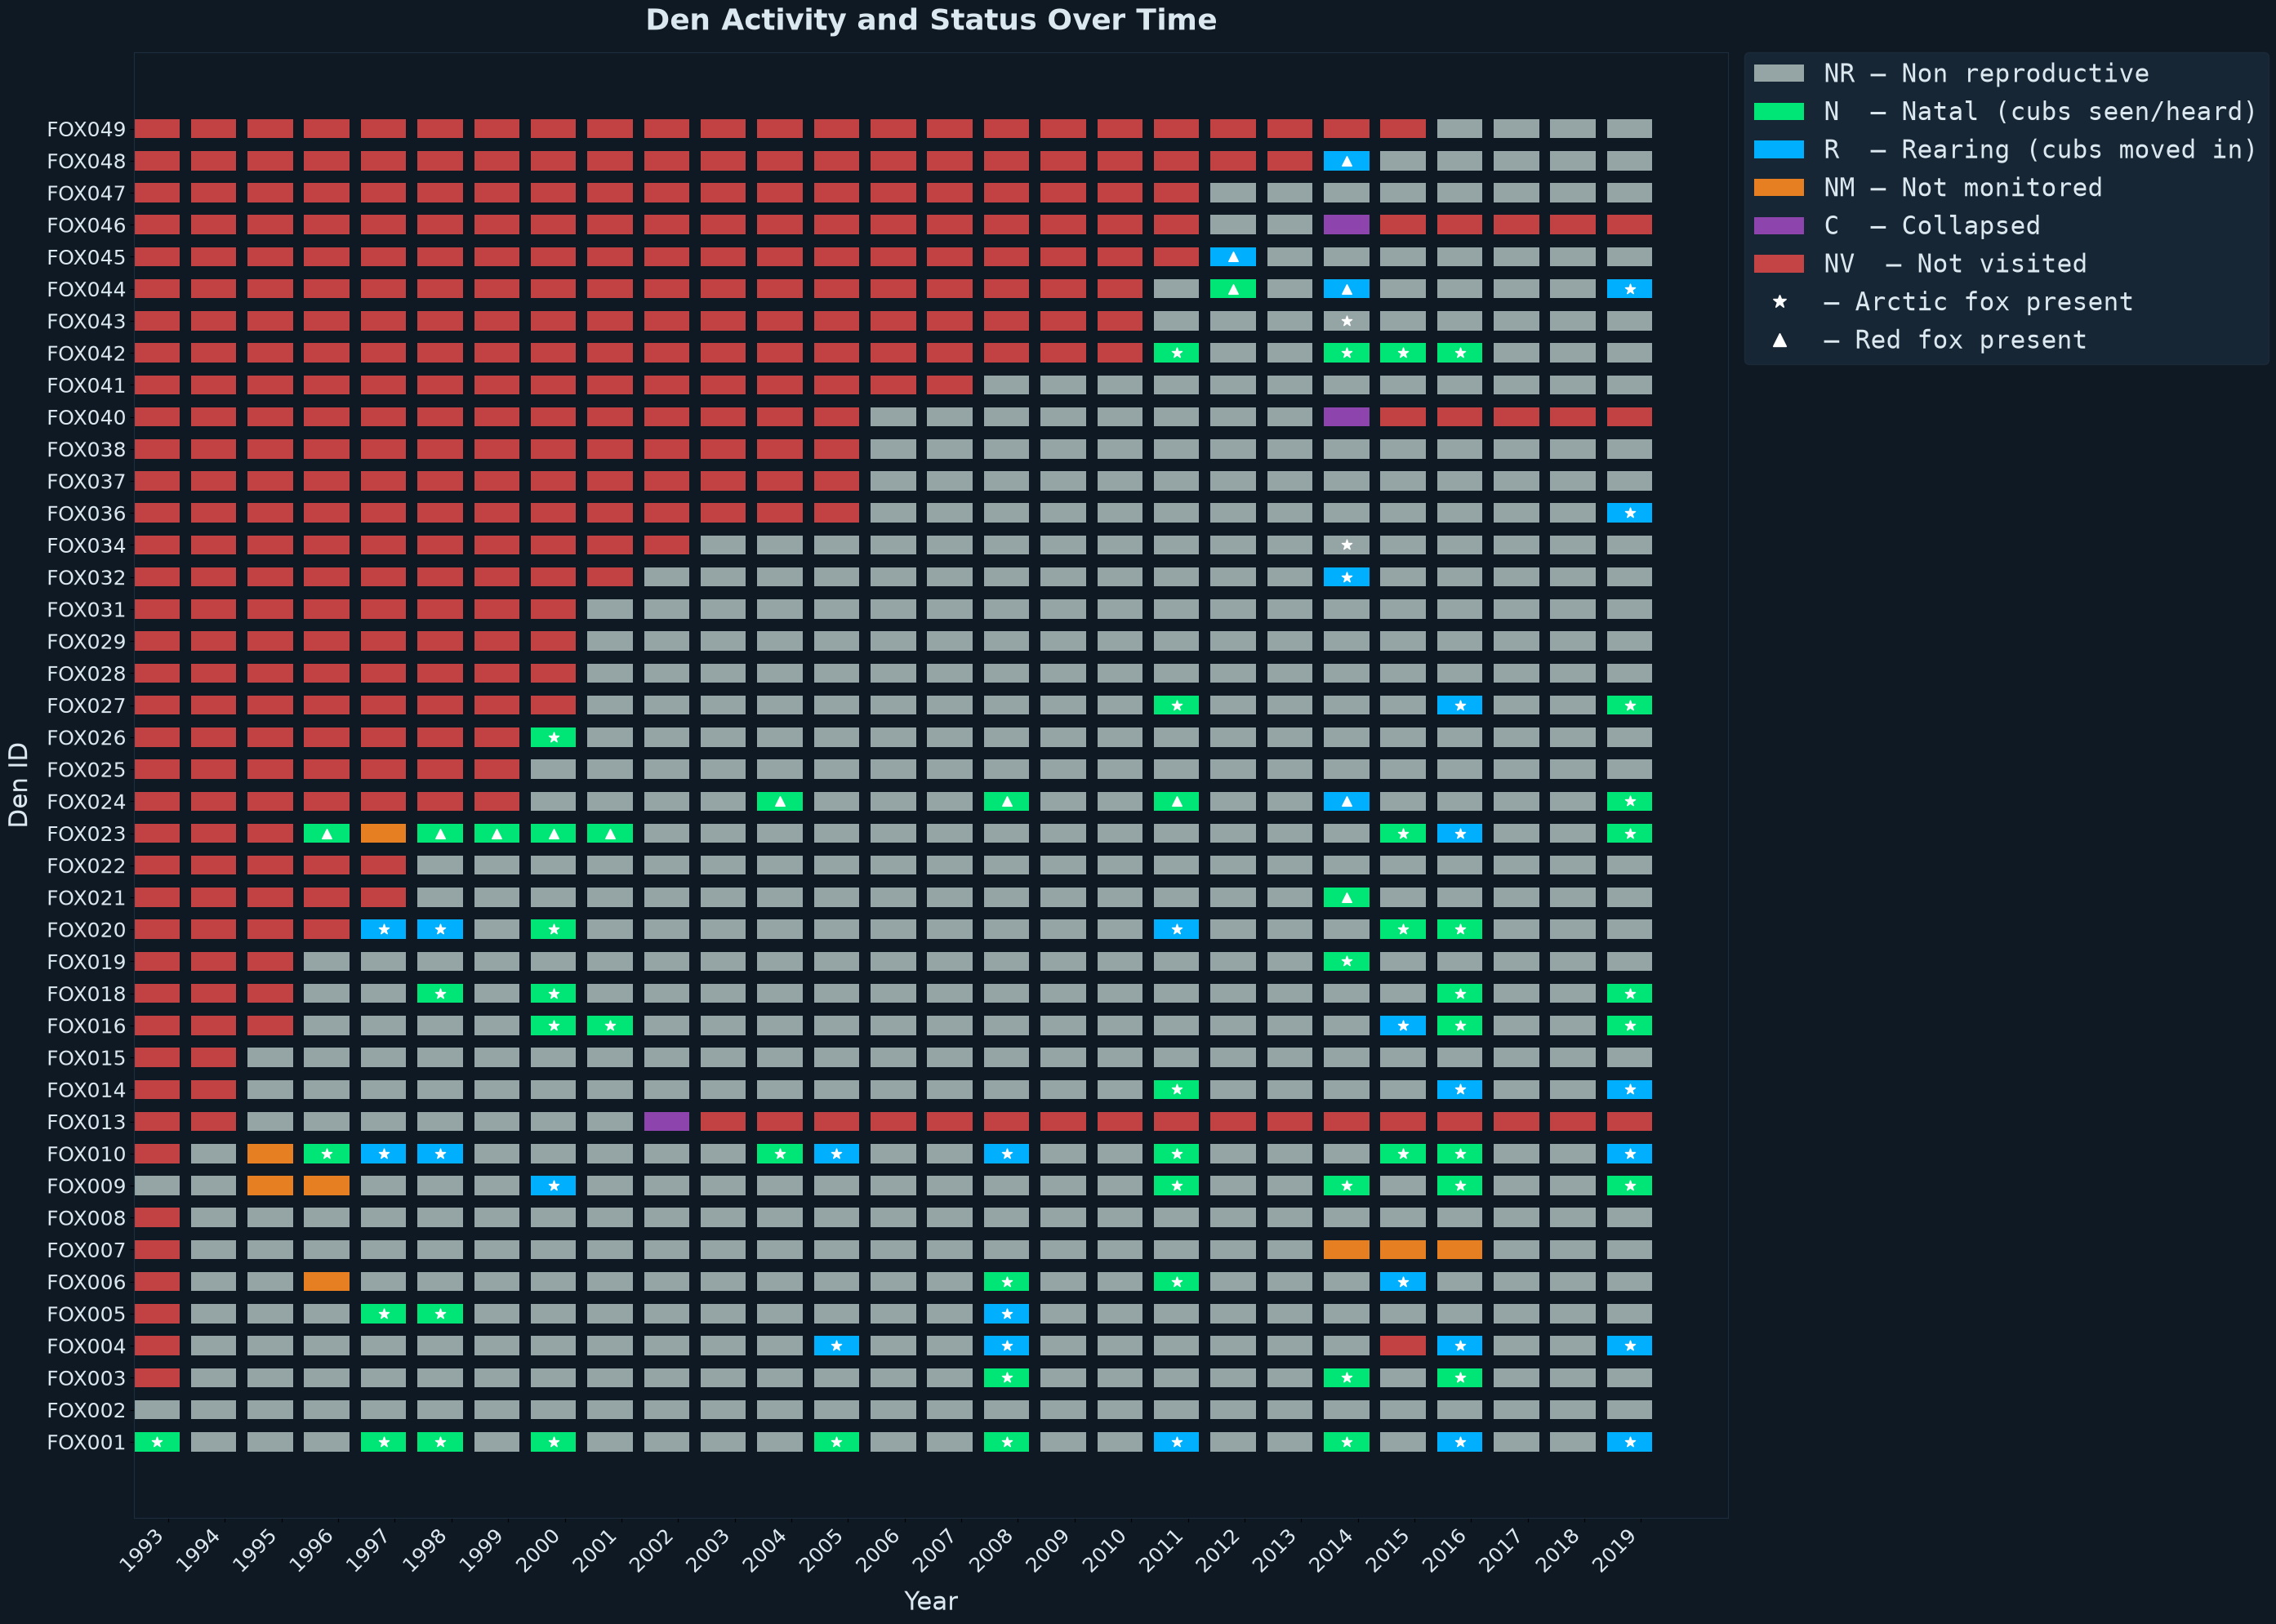

In [34]:
fig, ax = plt.subplots(figsize=(28, 20))
fig.patch.set_facecolor('#0f1923')
ax.set_facecolor('#0f1923')

# draw not-visited bars first
for den in den_ids:
    for year in all_years:
        if (den, year) not in visited_dens:
            y = den_y[den]
            ax.barh(y, width=0.8, left=year, height=0.6,
                    color='#e34948', alpha=0.85, edgecolor='none', align='center')
# color='#e34948'
# draw actual status bars
for _, row in select_valley_den_data.iterrows():
    y = den_y[row['Den_ID']]
    color = colors.get(row['Status'], 'white')
    ax.barh(y, width=0.8, left=row['Year'], height=0.6,
            color=color, edgecolor='none', align='center')

    if row['Species'] == 'arctic fox':
        ax.scatter(row['Year'] + 0.4, den_y[row['Den_ID']],
                   color='white', s=85, zorder=6, marker='*')

    if row['Species'] == 'red fox':
        ax.scatter(row['Year'] + 0.4, den_y[row['Den_ID']],
                   color='white', s=70, zorder=6, marker='^')

# y axis — den IDs
ax.set_yticks(range(len(den_ids)))
ax.set_yticklabels(den_ids, fontsize=18, color='#dce8f0')

# x axis — shift labels to sit under bars (offset by 0.5)
ax.set_xticks([y + 0.6 for y in all_years])
ax.set_xticklabels(all_years, rotation=45, fontsize=18,
                   color='#dce8f0', ha='right')

ax.set_xlabel('Year', fontsize=22, color='#dce8f0', labelpad=12)
ax.set_ylabel('Den ID', fontsize=22, color='#dce8f0', labelpad=12)
ax.set_title('Den Activity and Status Over Time', fontsize=26,
             color='#dce8f0', fontweight='bold', pad=20)

# spines
for spine in ax.spines.values():
    spine.set_edgecolor('#1e2d3d')

# legend
legend_elements = [
    mpatches.Patch(facecolor='#95a5a6', label='NR — Non reproductive'),
    mpatches.Patch(facecolor='#00e676', label='N  — Natal (cubs seen/heard)'),
    mpatches.Patch(facecolor='#00b0ff', label='R  — Rearing (cubs moved in)'),
    mpatches.Patch(facecolor='#e67e22', label='NM — Not monitored'),
    mpatches.Patch(facecolor='#8e44ad', label='C  — Collapsed'),
    mpatches.Patch(facecolor='#e34948', label='NV  — Not visited', alpha=0.85),
    mlines.Line2D([], [], color='white', marker='*', linestyle='None',
                  markersize=12, label='— Arctic fox present'),
    mlines.Line2D([], [], color='white', marker='^', linestyle='None',
                  markersize=12, label='— Red fox present')
]

ax.legend(handles=legend_elements,
          facecolor='#1a2a3a', edgecolor='#1e2d3d', labelcolor='#dce8f0',
          prop={'family': 'monospace', 'size': 22}, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

In [17]:
arctic_fox_data = select_valley_den_data[
    select_valley_den_data['Species'] == 'arctic fox'
]

total_foxes = select_valley_den_data[
    (select_valley_den_data['Species'] == 'arctic fox') |
    (select_valley_den_data['Species'] == 'red fox')
]

In [20]:
n_counts_foxes = total_foxes[total_foxes['Status'] == 'N'].groupby('Den_ID').size().reindex(den_ids, fill_value=0)
n_counts_arctic_fox = arctic_fox_data[arctic_fox_data['Status'] == 'N'].groupby('Den_ID').size().reindex(den_ids, fill_value=0)

In [21]:
n_per_year_total = (total_foxes[total_foxes['Status'] == 'N']
                       .groupby('Year').size()
                       .reindex(all_years, fill_value=0))

# count N per year — Arctic fox only
n_per_year_af_only = (arctic_fox_data[arctic_fox_data['Status'] == 'N']
                      .groupby('Year').size()
                      .reindex(all_years, fill_value=0))

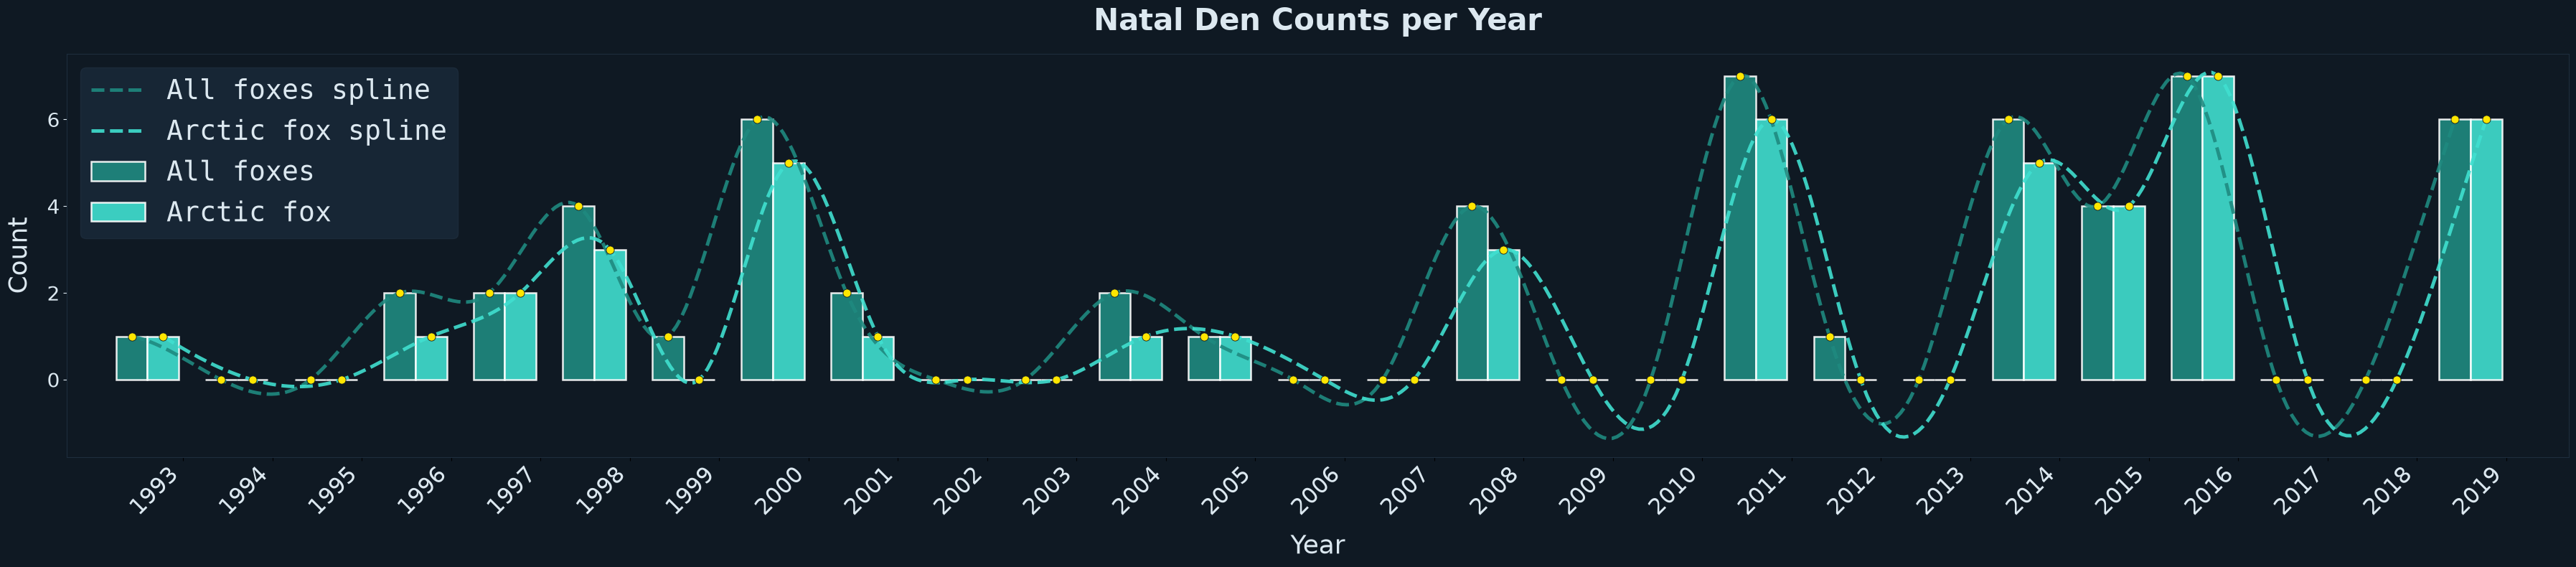

In [42]:
from scipy.interpolate import make_interp_spline

fig2, ax2 = plt.subplots(figsize=(36, 8))
fig2.patch.set_facecolor('#0f1923')
ax2.set_facecolor('#0f1923')

x_min = min(all_years) - 0.5
x_max = max(all_years) + 1.5

bar_width = 0.35
x = np.array(all_years)

ax2.bar(x + 0.4 - bar_width/2, n_per_year_total, width=bar_width,
        color='#1f8a80', alpha=0.9, label='All foxes',
        edgecolor='white', linewidth=1.8)
ax2.bar(x + 0.4 + bar_width/2, n_per_year_af_only, width=bar_width,
        color='#40e0d0', alpha=0.9, label='Arctic fox',
        edgecolor='white', linewidth=1.8)

# spline fits for both series, aligned to each bar's own center
years_arr = np.array(all_years, dtype=float)
fit_x = np.linspace(years_arr.min(), years_arr.max(), 500)

spline_total = make_interp_spline(years_arr, n_per_year_total.values.astype(float), k=3)
spline_af = make_interp_spline(years_arr, n_per_year_af_only.values.astype(float), k=3)

ax2.plot(fit_x + 0.4 - bar_width/2, spline_total(fit_x), color='#1f8a80', linewidth=3.5,
         linestyle='--', alpha=0.9, label='All foxes spline')
ax2.plot(fit_x + 0.4 + bar_width/2, spline_af(fit_x), color='#40e0d0', linewidth=3.5,
         linestyle='--', alpha=0.9, label='Arctic fox spline')

# yellow markers at each bar top (spline/data intersection)
ax2.scatter(x + 0.4 - bar_width/2, n_per_year_total.values, color='#ffe600',
            s=65, zorder=6, edgecolor='#0f1923', linewidth=0.6)
ax2.scatter(x + 0.4 + bar_width/2, n_per_year_af_only.values, color='#ffe600',
            s=65, zorder=6, edgecolor='#0f1923', linewidth=0.6)

ax2.set_xlim(x_min, x_max)
ax2.set_xticks([y + 0.8 for y in all_years])
ax2.set_xticklabels(all_years, rotation=45, fontsize=22,
                    color='#dce8f0', ha='right')
ax2.set_ylabel('Count', fontsize=26, color='#dce8f0', labelpad=14)
ax2.set_xlabel('Year', fontsize=26, color='#dce8f0', labelpad=14)
ax2.tick_params(axis='y', colors='#dce8f0', labelsize=20)
ax2.set_title('Natal Den Counts per Year', fontsize=30,
              color='#dce8f0', fontweight='bold', pad=24)
ax2.legend(prop={'family': 'monospace', 'size': 27},
           facecolor='#1a2a3a', edgecolor='#1e2d3d', labelcolor='#dce8f0')

for spine in ax2.spines.values():
    spine.set_edgecolor('#1e2d3d')

plt.tight_layout()
plt.show()

In [43]:
natal_dens_per_year = pd.DataFrame({
    'Year': all_years,
    'All_foxes_natal_dens': n_per_year_total.values,
    'Arctic_fox_natal_dens': n_per_year_af_only.values
})
natal_dens_per_year.to_csv('data/saved/natal_dens_per_year.csv', index=False)